# Wildfire Activity and Plume Rise Modeling Framework:
# 2020 Creek Fire
***
## Overview of the First Order Fire Effects Model (FOFEM)

FOFEM was developed by the United States Forest Service (USFS) and is used to assess fuel consumption, fire behavior, smoke and soil heating, and smoke emissions. FOFEM does not assume that 100% of the fuel is consumed during combustion and uniquely distinguishes between the flaming and smoldering stages of burning: the flaming stage of fire is associated with the high-intensity (>15 kW m-2) active head of a fire, while smoldering represents longer-duration residual burning at a lower intensity (<15 kW m-2). 

##### Inputs to FOFEM include: 
- Temperature
- Wind Speed
- Fuel Moisture (1hr-1000hr)
    - Note: Dead fuels are classified by their diameter and the time it takes for them to gain or lose moisture
- Wildfire Location (lat/lon)
- Vegetation/fuel types

##### Outputs include: 
- Heat fluxes (kW m-2)
- Emissions of key species (e.g. PM2.5, PM10, CO2)
- Fuel Consumption (tons/acre)

### Let's run FOFEM for a sample case during the 2020 Creek Fire
The 2020 Creek Fire broke out in the Sierra National Forest in California's Central Valley, burning approximately 380,000 acres before it was 100% contained. Notably, the Creek Fire produced a large pyroCb, reaching ~15.5 km MSL, and was one of the largest non-complex fires (from a single source, not a group of fires) in California history. The Creek Fire also exhibited erratic fire behavior likely driven by increased surface fuel loading, drought, and a record-breaking heat wave in the region. A widespread bark beetle infestation at the time led to above-average accumulation of dead fuels at the surface.

##### First load in necessary libraries and open pre-generated FOFEM inputs for the Creek Fire:

In [1]:
import os
original_cwd = os.getcwd() 
import numpy as np
import pandas as pd
import math
import datetime as dt
from scipy import stats
import numpy.ma as ma
import matplotlib.pyplot as plt
from pathlib import Path
import multiprocessing as mp
import csv
import sys
import warnings
warnings.filterwarnings('ignore')

### Import functions
from functions_process_fofem_outputs import agg_fofout, process_outputs, chunk_by_group, calc_mean_heatflux, calc_rel_burnarea

In [2]:
### Open FOFEM inputs for the Creek Fire
ROOT = Path.cwd().parents[0]
creek_inputs_path = ROOT / "src" / "get_fofem_inputs" / "2020_creekfire_FA_fofem_inputs.csv"
creek_inputs = pd.read_csv(creek_inputs_path, sep=",")

### To speed up FOFEM runs only initialize runs for Sugar pine -- Douglas-fir -- oak forest
# Group by datetime and grab first row for each hour
fof_inputs = creek_inputs.groupby('date_time').head(1)
fof_inputs['fuelbed_name'] = 39  # Corresponds to the Sugar pine -- Douglas-fir -- oak forest (37.51 tons/acre) fuel class

# Select the first few days of the Creek Fire, or filter to a time period of interest
fof_inputs['date_time'] = pd.to_datetime(fof_inputs['date_time'], format='%Y%m%d%H')
fof_inputs = fof_inputs[(fof_inputs['date_time'] >= '2020-09-04 21:00:00') & (fof_inputs['date_time'] <= '2020-09-08 23:00:00')].copy()
fof_inputs['date_time'] = fof_inputs['date_time'].dt.strftime('%Y%m%d%H')

### Quick Visualization of FOFEM environmental conditions

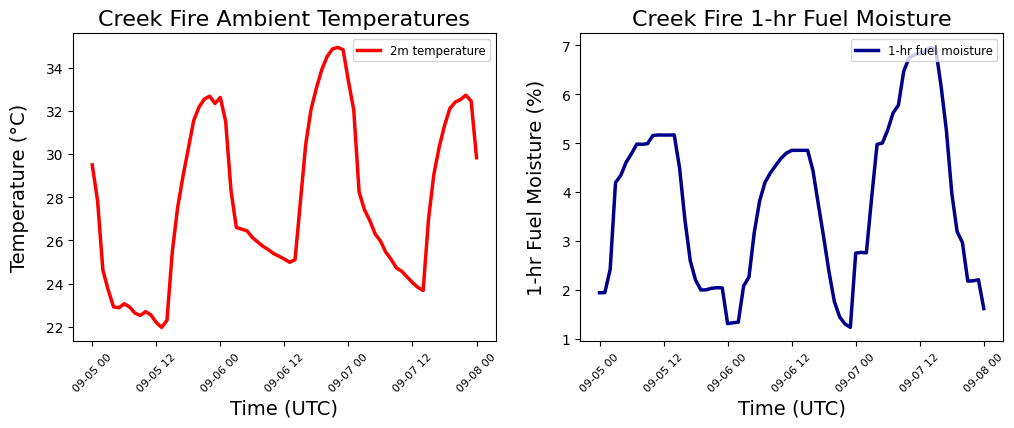

In [3]:
### Visualize fuel moisture and meteorological condition changes
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Convert datetime columns
fof_inputs['date_time'] = pd.to_datetime(fof_inputs['date_time'], format='%Y%m%d%H')

# Filter FOFEM inputs to first full 3 days
fof_inputs = fof_inputs[(fof_inputs['date_time'] >= '2020-09-05 00:00:00') & (fof_inputs['date_time'] <= '2020-09-08 00:00:00')]

# Plot temperatures and 1-hr fuel moisture
ax.plot(fof_inputs['date_time'], fof_inputs['ambient_temp'], color = 'red', label = f"2m temperature", linewidth=2.5)
ax2.plot(fof_inputs['date_time'], fof_inputs['fmois1h'] * 100, color = 'darkblue', label = f"1-hr fuel moisture", linewidth=2.5)

# Set titles and add x-axis labels
ax.set_title(f"Creek Fire Ambient Temperatures", size=16)
ax2.set_title(f"Creek Fire 1-hr Fuel Moisture", size=16)
ax.set_xlabel('Time (UTC)', size=14)
ax2.set_xlabel('Time (UTC)', size=14)

# set font and rotation for date tick labels
ax.tick_params(axis='x', labelsize=8,rotation=45,which='major')
ax2.tick_params(axis='x', labelsize=8,rotation=45,which='major')

# Set y-axis labels and add figure legends
ax.set_ylabel(f"Temperature (°C)", size = 14, labelpad = 12)
ax2.set_ylabel(f"1-hr Fuel Moisture (%)", size = 14, labelpad = 12)
ax.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes, fontsize= 'small')
ax2.legend(loc="upper right", bbox_to_anchor=(2.2,1), bbox_transform=ax.transAxes, fontsize= 'small')
plt.show()

### Run FOFEM! First switch to directory where FOFEM is installed

In [4]:
### Change working directory to where FOFEM is installed
from pathlib import Path
ROOT = Path.cwd().parent[0]
sys.path.append(str(ROOT / "models" / "fofem" / "modified_scripts"))

from mp_new_bulk_fofem_runs_flasmo import process_model_inputs

In [ ]:
### Run FOFEM in parallel, requires switching to directory where FOFEM is installed
if __name__ == '__main__':
    # Create the num_name_dict from fccs_path
    num_name_dict = {}
    project_root = Path.cwd().parents[2]
    fccs_fuelbeds_path =  os.path.join(project_root, "fofem_python","src","py_fofem","data", "fof_fccs.csv")

    #make dictionary of fofem fuelbed names and fofem fuelbed numbers (universal)
    with open(fccs_fuelbeds_path, mode='r') as fccs_file:
        reader = csv.reader(fccs_file)
        next(reader)  # Skip header if there is one
        for row in reader:
            num_name = row[4]
            num, name = num_name.split(' ', 1)
            num_name_dict[int(num)] = num_name

    # Replace fuelbed numbers with names
    fof_inputs['fuelbed_name'] = fof_inputs['fuelbed_name'].astype(int).map(num_name_dict).fillna('')

    # Convert DataFrame to list of rows (like your original model_inputs)
    model_inputs = fof_inputs.values.tolist()

    # Process inputs in parallel
    output_totals_array = process_model_inputs(model_inputs, num_name_dict)

    # Convert output array to DataFrame
    totals_headers = ["lat", "lon", "date_time", "fuelbed_name", "timestep", "fmois1kh", "fmois100h", "fmois10h", "fmois1h", "fmoislit", "fmoisduff", "percent_crown_burn", "fuelcat", "dufftype", "met_dat_path", "ambient_temp", "windspeed", "emission_factors", "fire_type","con_ob", "consumed_flaming", "consumed_smoldering", "pm25_fla", "pm25_smo", "pm10_fla", "pm10_smo", "co_fla", "co_smo", "co2_fla", "co2_smo", "ch4_fla", "ch4_smo", "nox_fla", "nox_smo", "so2_fla", "so2_smo", "fi", "crown_fi",  "timeidx","fire_id","hourly_growth","FCCS_class_percent"]
    output_df = pd.DataFrame(output_totals_array, columns=totals_headers)
    
    # Filter out rows where columns 22-33 are all zeros
    fofem_outputs = output_df.loc[~(output_df.iloc[:, 22:34] == 0).all(axis=1)].copy()

    # Write output arrays to CSV files
    def write_output_to_csv(output_totals_array):
        # Path to output file (set to location where you want to save outputs)
        model_totals_path = os.path.join('/................')
        
        # Write output_totals_array to output CSV
        with open(model_totals_path, mode='w', newline='') as outfile:
            writer = csv.writer(outfile)
            writer.writerow(totals_headers)  # Write the header
            for row in output_totals_array:
                # Check if the first six columns are all zeroes
                if not all(value == 0 for value in row[22:34]):     # Check columns pm25 to fi (emissions and fire intensity) for when they are not all equal to zero
                    writer.writerow(row)
    
        print(f"Output written to {model_totals_path}")

    #  Write FOFEM outputs to CSV
    # write_output_to_csv(output_totals_array)

### Let's clean up the FOFEM outputs, averaging heat fluxes and emissions by hour. 

In [6]:
### Clean up raw FOFEM outputs
# Switch back to original working directory
original_cwd = os.getcwd() 

# Average outputs by hour for each fuel category
if __name__ == '__main__':
    
    # Add flaming + smoldering emissions of a few key species
    fofem_outputs['pm25'] = fofem_outputs['pm25_fla'] + fofem_outputs['pm25_smo']
    
    fofem_outputs['pm10'] = fofem_outputs['pm10_fla'] + fofem_outputs['pm10_smo']
   
    fofem_outputs['co2'] = fofem_outputs['co2_fla'] + fofem_outputs['co2_smo']

    # Clean up FOFEM outputs, takes care of fuels that burn less than an hour or for multiple hours
    cleaned_outputs = process_outputs(fofem_outputs, 0)

In [7]:
### Calculate weighted heat fluxes (based on fuel classes)
cleaned_outputs['fire_year'] = cleaned_outputs['date_time'].dt.year
mean_hf = cleaned_outputs.groupby(['fire_id', 'fire_year']).apply(calc_mean_heatflux).reset_index(drop=True)
mean_hf = mean_hf.dropna()

mean_hf['fire_year'] = mean_hf['date_time'].dt.year
mean_hf = mean_hf.sort_values(by=['fire_year','fire_id'])

### Plot the FOFEM-calculated heat fluxes for the first 3 days of the Creek Fire

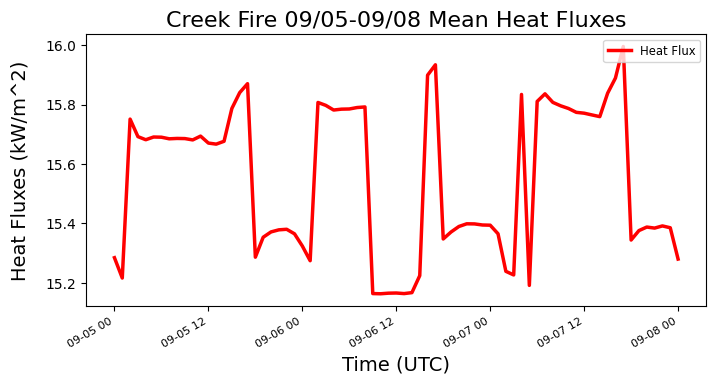

In [8]:
### Plot heat fluxes for a period during the Creek Fire
fig, ax = plt.subplots(figsize=(8,4))
mean_hf = mean_hf[(mean_hf['date_time'] >= '2020-09-05 00:00:00') & (mean_hf['date_time'] <= '2020-09-08 00:00:00')]

# Plot hourly averaged heat fluxes
ax.plot(mean_hf['date_time'], mean_hf['weighted_fi'], color = 'red', label = f"Heat Flux", linewidth=2.5)

# Set axis labels
ax.set_xlabel('Time (UTC)', size=14)
ax.set_ylabel(f"Heat Fluxes (kW/m^2)", size = 14, labelpad = 12)

# Set plot title and add legend
ax.set_title(f"Creek Fire 09/05-09/08 Mean Heat Fluxes", size=16)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes, fontsize= 'small')

# Set font and rotation for date tick labels
ax.tick_params(axis='x', labelsize=8,rotation=45,which='major')
plt.gcf().autofmt_xdate() 
plt.show()

###  Let's calculate and plot total consumption amounts (in tons/acre) each hour

In [9]:
### Calculate total fuel consumption by adding flaming and smoldering consumption
fofem_outputs['total_consumed'] = fofem_outputs['consumed_flaming'] + fofem_outputs['consumed_smoldering']

# Get consumption for each hour
total_cons = fofem_outputs.groupby('date_time')[['total_consumed', 'consumed_smoldering','consumed_flaming']].first()

total_cons = total_cons.reset_index(drop=False)

# Datetime conversions
total_cons['date_time'] = pd.to_datetime(total_cons['date_time'], format='%Y%m%d%H')

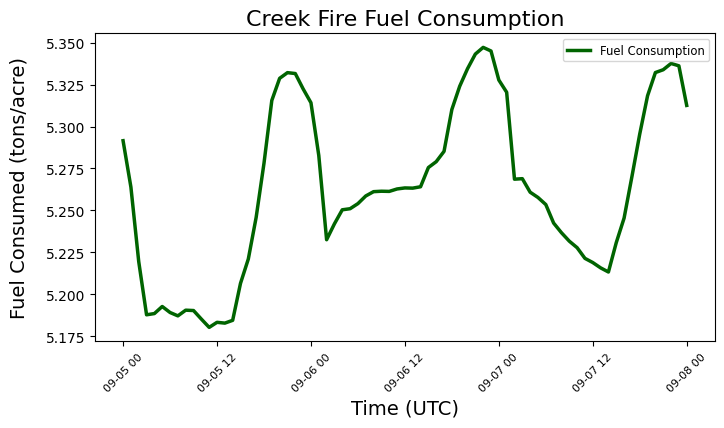

In [10]:
### Plot hourly consumption (tons/acre) for the first full 3 days of the fire
fig, ax  = plt.subplots(figsize=(8, 4))
total_cons = total_cons[(total_cons['date_time'] >= '2020-09-05 00:00:00') & (total_cons['date_time'] <= '2020-09-08 00:00:00')]

# Plot fuel consumption
ax.plot(total_cons['date_time'], total_cons['total_consumed'], color = 'darkgreen', label = f"Fuel Consumption", linewidth=2.5)

# Set plot titles and axis labels
ax.set_title(f"Creek Fire Fuel Consumption", size=16)
ax2.set_title(f"Creek Fire Smoldering Consumption", size=16)
ax.set_xlabel('Time (UTC)', size=14)
ax2.set_xlabel('Time (UTC)', size=14)
ax.set_ylabel(f"Fuel Consumed (tons/acre)", size = 14, labelpad = 12)

# set font and rotation for date tick labels
ax.tick_params(axis='x', labelsize=8,rotation=45,which='major')
ax2.tick_params(axis='x', labelsize=8,rotation=45,which='major')

# Add plot legends
ax.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes, fontsize= 'small')
ax2.legend(loc="upper right", bbox_to_anchor=(2.2,1), bbox_transform=ax.transAxes, fontsize= 'small')
plt.show()

## Now let's run the Freitas et al. 2010 plume rise model!

#### Inputs to the Freitas model include:
- Heat fluxes (kW m-2)
- Active burn area (m2)
- Thermodynamic profile
- Entrainment coefficient
    - Note: this controls the amount of cooler, environmental air entrained into the plume 
- Wind shear effects (off/on)

#### Outputs include:
- Plume top height (AGL)
- detrainment profile

### First import functions from the modified plume rise model scripts

In [11]:
### Change working directory to where the Freitas plume rise model is installed
from pathlib import Path
ROOT = Path.cwd().parent[0]
sys.path.append(str(ROOT / "models" / "freitas_prm" / "modified_scripts"))

from MP_FA_multi_plume_rise_demo import process_row, worker_init, process_row_parallel

In [ ]:
### Format datetime
mean_hf['new_datetime'] = pd.to_datetime(mean_hf['new_datetime']).dt.strftime("%Y-%m-%dT%H:%M:%S")

## Convert hourly growth from acres to m^2
mean_hf['hourly_growth'] = mean_hf['hourly_growth'] * 4046.86 

### Parallelize
def process_row_parallel(row):
    result = process_row(row)
    return result

if __name__ == "__main__":
    num_processes = int(os.environ.get("SLURM_CPUS_PER_TASK", mp.cpu_count()))

    # Use existing DataFrame directly
    model_inputs = mean_hf.values.tolist()

    # Optional if you still need headers
    header = mean_hf.columns.tolist()

    with mp.Pool(
        processes=num_processes,
        initializer=worker_init
    ) as pool:
        results = pool.map(process_row_parallel, model_inputs)

    for pid in pool._pool:
        worker_dir = f"/tmp/worker_{pid}_"  #make sure that temporary directories for each worker process are deleted
        if os.path.exists(worker_dir):
            shutil.rmtree(worker_dir, ignore_errors=True)
    
    # Write results to CSV files
    cols = ['date_time', 'lat', 'lon', 'fire_id', 'fire_area', 'heat_flux', 'pth', 'output_filepath']
    print(results)
    output_df = pd.DataFrame(results, columns=cols)
    
    # Output plume rise model outputs, update to a preferred output directory
    # output_df.to_csv('path/to/output/5_26_creek_demo_pr_out.csv', index=False)


## Plot a time series of plume top heights for the Creek Fire

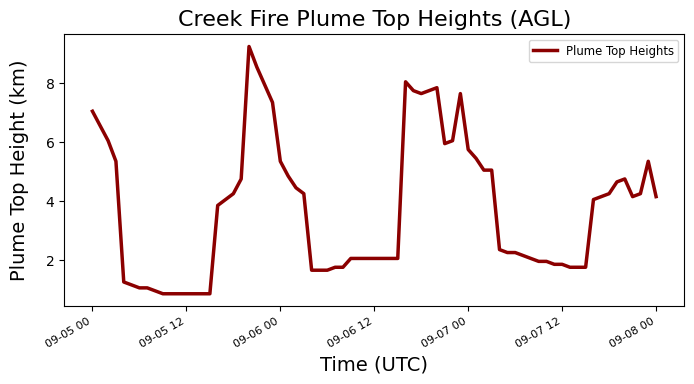

In [13]:
### Plot plume rise heights for the first few days of the Creek Fire
fig, ax  = plt.subplots(figsize=(8, 4))

# Plot plume top heights
output_df['date_time'] = pd.to_datetime(output_df['date_time'])
ax.plot(output_df['date_time'], output_df['pth'], color = 'darkred', label = f"Plume Top Heights", linewidth=2.5)

# Set plot titles and axis labels
ax.set_title(f"Creek Fire Plume Top Heights (AGL)", size=16)
ax.set_xlabel('Time (UTC)', size=14)
ax.set_ylabel(f"Plume Top Height (km)", size = 14, labelpad = 12)

# set font and rotation for date tick labels
ax.tick_params(axis='x', labelsize=8,rotation=45,which='major')

# Add plot legends
ax.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes, fontsize= 'small')
plt.gcf().autofmt_xdate() 
plt.show()